# Applied Data Science Project - Formula One Pit Stop Analysis
## By: Iseah Hasan
--------------------------------------------------------------------
## Overview
This project focuses on modeling/predicting race strategy decisions in Formula One, emphasizing on pit stop behavior. In Formula One, race outcomes are not just dependent on a driver's skill or their car, but also race strategies used by racing teams, which involve a multitude of factors, such as tire compound choice and pit stop timing. In this case, this project focuses slightly more on the pit stop aspect, which will eventually begin to involve some other factors as well. Nonetheless, in order to better align with the objective of analyzing overall strategies, the data was transformed to represent each driver's strategy within a race. The main primary goal of this project is to build a model that predicts the number of pit stops a driver will make in a given race, along with analyzing different patterns in the data to gain more insight into different factors influencing race strategy.

In [31]:
# import all necessary libraries:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

## Data Collection
The dataset used in this project is an F1 pit stop performance dataset sourced from Kaggle (https://www.kaggle.com/datasets/eshummalik/pitstop-pulse-formula-1-performance-data), loaded via a CSV file with Pandas. Each row in the dataset represents a single pit stop made during F1 history, and contains variables like Race, RaceId, DriverName, DriverId, Car, Lap, and so on.

In [2]:
fileName = 'pitstops.csv'
f1_pitStops = pd.read_csv(fileName)
f1_pitStops

,RaceId,DriverId,Stops,Year,Race,No,DriverName,Code,Car,Lap,TimeOfDay,Time,Total
0,258,100,1,1994,pacific,20,Erik Comas,COM,Larrousse Ford,1,14:01:34,49.111,49.111
1,258,79,1,1994,pacific,3,Ukyo Katayama,KAT,Tyrrell Yamaha,17,14:20:46,28.482,28.482
2,258,57,1,1994,pacific,7,Mika Hakkinen,HAK,McLaren Peugeot,18,14:22:35,43.745,43.745
3,258,71,1,1994,pacific,0,Damon Hill,HIL,Williams Renault,18,14:23:00,21.992,21.992
4,258,105,1,1994,pacific,24,Michele Alboreto,ALB,Minardi Ford,19,14:24:39,27.693,27.693
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9916,355,18,1,2010,abu-dhabi,1,Jenson Button,BUT,McLaren Mercedes,39,18:15:38,20.511,20.511
9917,355,10,1,2010,abu-dhabi,24,Timo Glock,GLO,Virgin Cosworth,40,18:19:37,20.93,20.93
9918,355,5,1,2010,abu-dhabi,19,Heikki Kovalainen,KOV,Lotus Cosworth,41,18:21:05,21.537,21.537
9919,355,9,1,2010,abu-dhabi,11,Robert Kubica,KUB,Renault,46,18:27:56,20.188,20.188


## Initial Data Exploration
For this part, I used info() and describe() to gain a basic understanding of all the columns and their corresponding datatypes, as well as the basic distribution of all of the numerical stats of the dataset.

In [3]:
f1_pitStops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9921 entries, 0 to 9920
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   RaceId      9921 non-null   int64 
 1   DriverId    9921 non-null   int64 
 2   Stops       9921 non-null   int64 
 3   Year        9921 non-null   int64 
 4   Race        9921 non-null   object
 5   No          9921 non-null   int64 
 6   DriverName  9921 non-null   object
 7   Code        9921 non-null   object
 8   Car         9920 non-null   object
 9   Lap         9921 non-null   int64 
 10  TimeOfDay   9921 non-null   object
 11  Time        9918 non-null   object
 12  Total       9921 non-null   object
dtypes: int64(6), object(7)
memory usage: 1007.7+ KB


In [4]:
f1_pitStops.describe()

,RaceId,DriverId,Stops,Year,No,Lap
count,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000
mean,142.586231,42.631791,1.607600,2002.527467,11.862312,29.613648
std,91.465460,85.404022,0.749017,4.816939,7.312977,13.890129
min,1.000000,1.000000,1.000000,1994.000000,0.000000,1.000000
25%,68.000000,15.000000,1.000000,1998.000000,5.000000,19.000000
50%,129.000000,25.000000,1.000000,2003.000000,11.000000,28.000000
75%,213.000000,53.000000,2.000000,2007.000000,18.000000,41.000000
max,355.000000,812.000000,6.000000,2010.000000,34.000000,73.000000


### Summary Stats
- Pit stop times have a relatively small spread, given its standard deviation, which indicates that most pit stops occur in a similar time range.
- Despite the small spread of the pit stop times, its standard deviation also suggest some variability due to varied consistency across different teams and some outliers, as a result of occasional anomalies like errors or mishaps.

## Data Cleaning
Since Time wasn't a numerical variable, I converted time into seconds by defining a function secs(t), with t being the original time. This essentially extracts the minute and second and converts them into float variables, then finally converting them into seconds. Finally, I then created some extra columns for these new variables, as well as the mode which all of these will be useful in the future.

In [5]:
## analyze pit stop time and total time (lap time + pitstop time):

# convert time to seconds: 
def secs(t):
    if pd.isna(t):
        return np.nan
    s = str(t).strip()
    if ":" in s:
        parts = s.split(":")
        if len(parts) == 2: 
            minute = float(parts[0])
            sec = float(parts[1])
            return (minute * 60 + sec)
    return float(s)

f1_pitStops["PitTime_Secs"] = f1_pitStops["Time"].apply(secs)
f1_pitStops["TotalTime_Secs"] = f1_pitStops["Total"].apply(secs)

# add mode: 
f1_pitStops.mode(numeric_only=True).iloc[0]


RaceId              45.000
DriverId            22.000
Stops                1.000
Year              2004.000
No                   5.000
Lap                 22.000
PitTime_Secs        25.888
TotalTime_Secs      22.260
Name: 0, dtype: float64

In [6]:
# view all other data including updated time:
f1_pitStops.describe()

,RaceId,DriverId,Stops,Year,No,Lap,PitTime_Secs,TotalTime_Secs
count,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9918.000000,9921.000000
mean,142.586231,42.631791,1.607600,2002.527467,11.862312,29.613648,33.173199,52.976807
std,91.465460,85.404022,0.749017,4.816939,7.312977,13.890129,51.713129,69.391070
min,1.000000,1.000000,1.000000,1994.000000,0.000000,1.000000,8.757000,0.000000
25%,68.000000,15.000000,1.000000,1998.000000,5.000000,19.000000,24.890750,28.164000
50%,129.000000,25.000000,1.000000,2003.000000,11.000000,28.000000,27.959000,41.869000
75%,213.000000,53.000000,2.000000,2007.000000,18.000000,41.000000,31.687750,60.132000
max,355.000000,812.000000,6.000000,2010.000000,34.000000,73.000000,1946.712000,1970.493000


In [7]:
# now gather just mean, mode, median, and sd into one visual:
basic_stats = f1_pitStops.describe().loc[['mean', 'std', '50%']]

# calculate mode and append to basic_stats:
mode = f1_pitStops.select_dtypes(include='number').mode().iloc[0]
basic_stats.loc['mode'] = mode

# display basic stats:
basic_stats

,RaceId,DriverId,Stops,Year,No,Lap,PitTime_Secs,TotalTime_Secs
mean,142.586231,42.631791,1.607600,2002.527467,11.862312,29.613648,33.173199,52.976807
std,91.465460,85.404022,0.749017,4.816939,7.312977,13.890129,51.713129,69.391070
50%,129.000000,25.000000,1.000000,2003.000000,11.000000,28.000000,27.959000,41.869000
mode,45.000000,22.000000,1.000000,2004.000000,5.000000,22.000000,25.888000,22.260000


## Exploratory Data Analysis (EDA)
To gain some more understanding of the dataset, along with relationships between variables, I first displayed frequency counts for all of the races, drivers, etc., then made some basic visualizations such as lap vs. pit time and pit time distribution by constructor (team).

In [8]:
# display frequency counts for each categorical column:
cat_cols = f1_pitStops.select_dtypes(include=['object']).columns
freq_counts = {}

for col in cat_cols:
    counts = f1_pitStops[col].value_counts()
    freq_counts[col] = counts

for col, counts in freq_counts.items():
    print(f"\nFrequency counts for {col}:")
    print(counts)


Frequency counts for Race:
Race
hungary          666
europe           649
spain            625
great-britain    610
japan            609
france           597
belgium          559
canada           542
australia        520
brazil           517
germany          502
san-marino       490
malaysia         437
italy            407
monaco           384
china            303
bahrain          279
united-states    246
turkey           220
austria          166
portugal         136
argentina        128
singapore        101
pacific           89
luxembourg        59
abu-dhabi         53
south-korea       27
Name: count, dtype: int64

Frequency counts for DriverName:
DriverName
Rubens Barrichello      499
Michael Schumacher      431
David Coulthard         400
Jarno Trulli            381
Giancarlo Fisichella    348
                       ... 
Roland Ratzenberger       2
Franck Lagorce            2
Markus Winkelhock         2
Philippe Alliot           1
Yannick Dalmas            1
Name: count, Length: 

### Categorical Insights:
- The dataset is highly imbalanced across races, with some races like Hungary (666 entries) and Europe (649 entries) appearing more frequently than others like Luxembourg (59 entries) or South Korea (27)
- Certain drivers like Michael Schumacher (431) and Rubens Barrichello (499) also appear significantly more frequently in the dataset than other drivers, where many of them only appear a few times.
- Similarly, teams like Ferrari (1036) and McLaren Mercedes also dominate the dataset, whereas several teams only appear a few times.
- This imbalanced distribution indicates that the original dataset is biased towards specific teams and drivers, typically more historically dominant teams, which may influence data analysis and modeling in the long run.

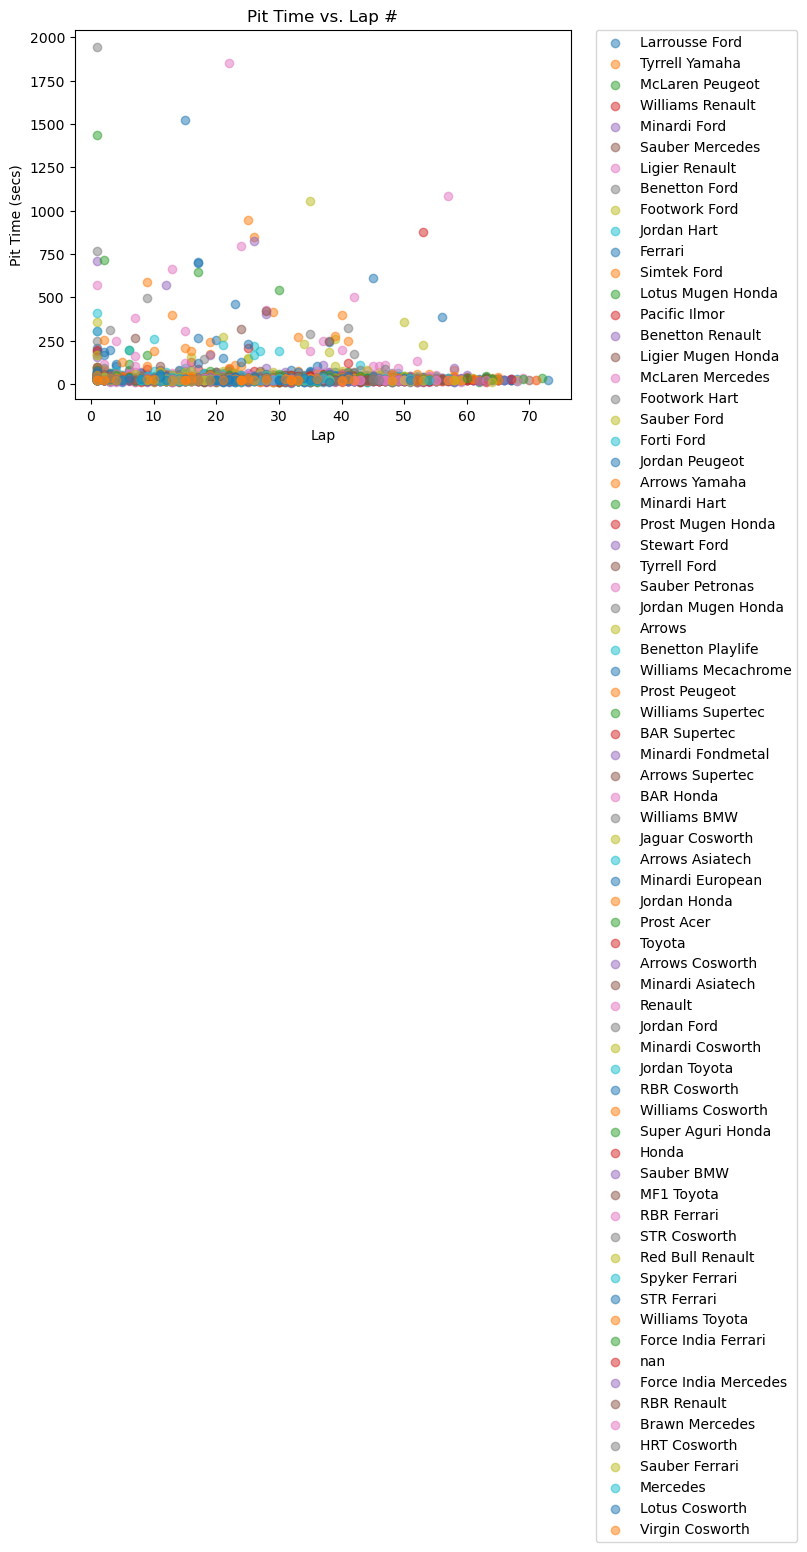

In [9]:
## create visualizations:

# scatterplot (lap vs. pit time): 
constructors = f1_pitStops['Car'].unique()
for constructor in constructors: 
    constructor_data = f1_pitStops[f1_pitStops['Car'] == constructor]
    plt.scatter(constructor_data['Lap'], constructor_data['PitTime_Secs'], label=constructor, alpha = 0.5)

plt.title('Pit Time vs. Lap #')
plt.xlabel('Lap')
plt.ylabel('Pit Time (secs)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()

### Pit Time vs. Lap Number
- Pit stop times remain relatively consistent across laps for the most part, with an exception for some outliers due to unanticipated circumstances
- There isn't any significant correlation between pit time and lap number, meaning that lap number does not have any impact on pit stop duration.
- Some level of variation exists between teams, which can indicate that efficiency matters more than timing the pit stop based on lap number.

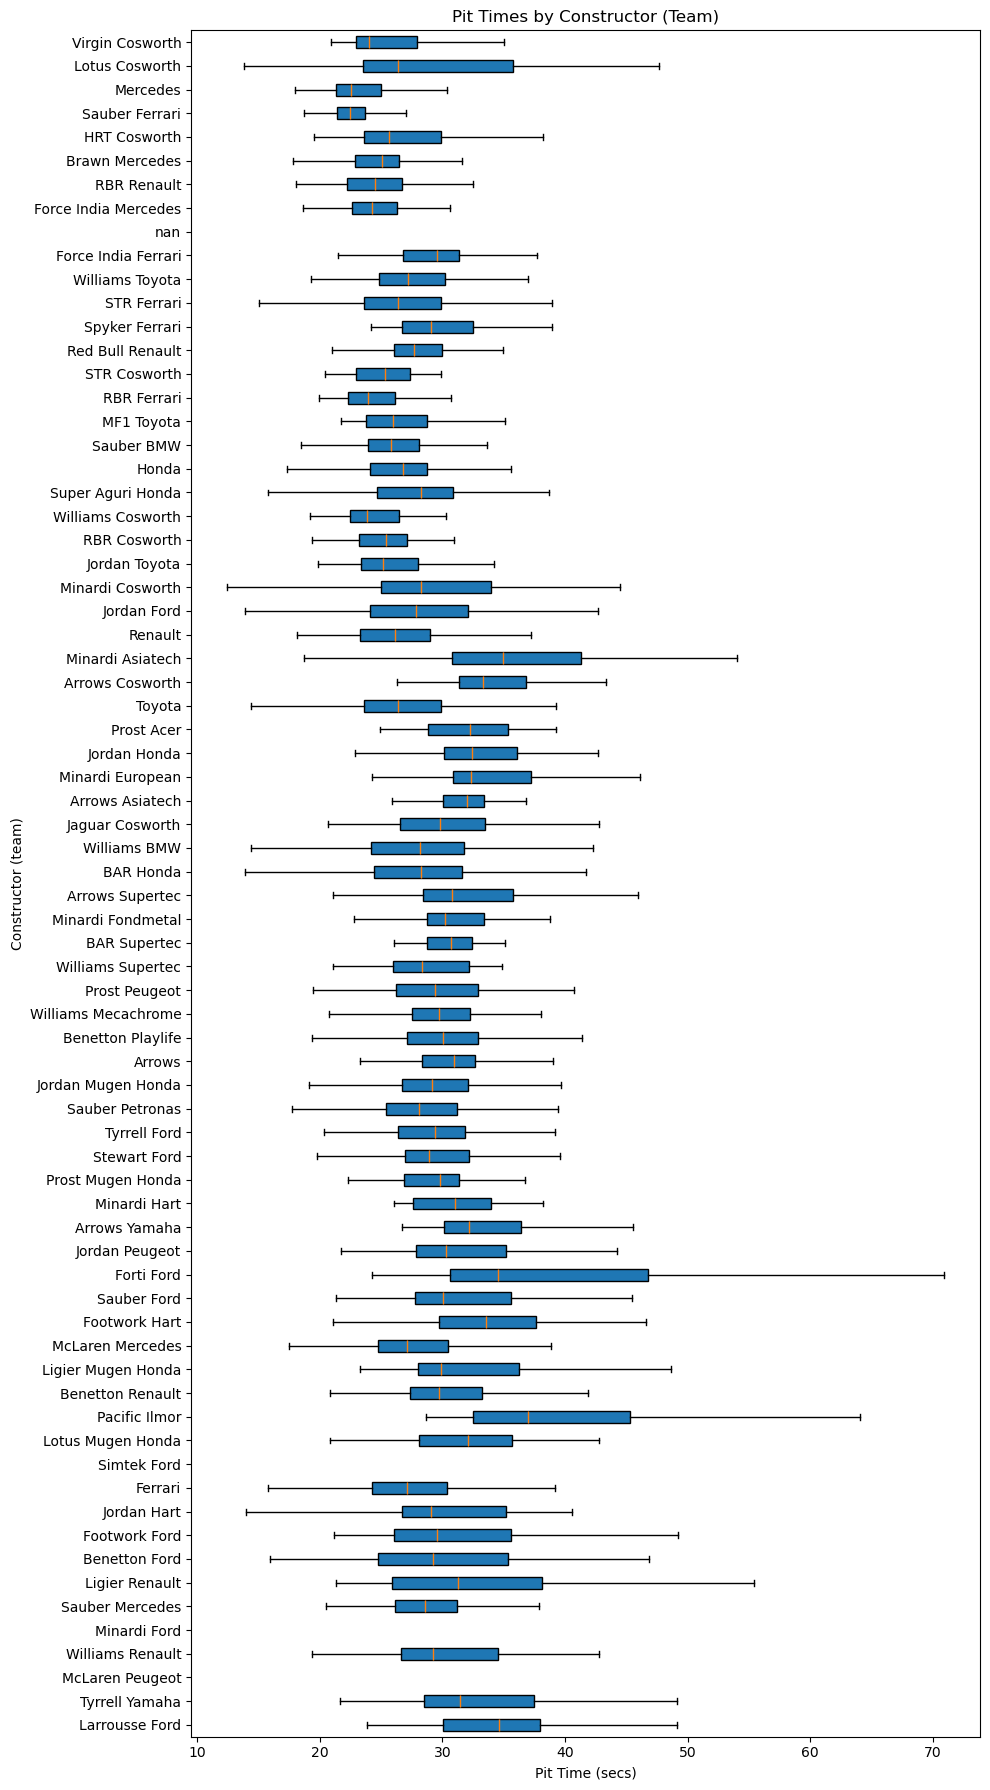

In [10]:
# create horizontal boxplot (pit times by constructor):
boxplot_data = []
for constructor in constructors:
    constructor_data = f1_pitStops[f1_pitStops['Car'] == constructor]
    boxplot_data.append(constructor_data['PitTime_Secs'].values)

plt.figure(figsize=(10, 18))
plt.boxplot(boxplot_data, labels=constructors, patch_artist=True, vert=False, showfliers=False)
plt.title('Pit Times by Constructor (Team)')
plt.xlabel('Pit Time (secs)')
plt.ylabel('Constructor (team)')
plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

### Pit Stop Times by Team
- The boxplot illustrates clear differences in pit stop performance across teams.
- Teams such as Ferrari, Mercedes, and McLaren tend to have lower median pit stop times compared to others.
- Some teams, for example, Forti Ford, show wider spreads of pit stop times, which suggest inconsistency in performance.
- The presence of outliers suggests occasional anomalies like errors/malfunctions, or racing conditions.

### Key Insights from Exploratory Data Analysis
- Pit stop time is largely independent of lap timing, suggesting that efficiency is more influential in determining performance.
- Most strategies and outcomes appear to follow consistent patterns, which indicate structure in race strategies.
- The original dataset is highly imbalanced across races, drivers, and teams, which can influence model behavior.
- These findings will be useful for the modeling phase, especially handling class imbalance and selecting relevant features as target variables in training/testing as well as modeling.

In [11]:
# normalize numeric cols for f1_pitstops
norm_cols = ['PitTime_Secs', 'TotalTime_Secs', 'Lap']
f1_pitStops_norm = f1_pitStops.copy()
scaler = MinMaxScaler()

# display normalized
f1_pitStops_norm[['PitTime_Norm', 'TotalTime_Norm', 'Lap_Norm']] = scaler.fit_transform(f1_pitStops_norm[norm_cols])
print(f1_pitStops_norm[norm_cols + ['PitTime_Norm', 'TotalTime_Norm', 'Lap_Norm']].head())

   PitTime_Secs  TotalTime_Secs  Lap  PitTime_Norm  TotalTime_Norm  Lap_Norm
0        49.111          49.111    1      0.020823        0.024923  0.000000
1        28.482          28.482   17      0.010178        0.014454  0.222222
2        43.745          43.745   18      0.018054        0.022200  0.236111
3        21.992          21.992   18      0.006829        0.011161  0.236111
4        27.693          27.693   19      0.009771        0.014054  0.250000


## Feature Engineering
Before proceeding onward, I needed to ensure that my categorical variables would be usable for machine learning, which is where OneHotEncoder comes in; I encoded all of the categorical variables (Race, DriverName, Code, and Car) with OneHotEncoder and then creaded a new df with the encoded variables. 
After encoding the categorical variables, I created new features measuring pit stop efficiency ratio and the pit strategy index to further analyze how efficient each driver's pit stops were, and whether they were early, average, or late.

In [12]:
# encode categorical cols w/ OneHotEncoder:
cat_cols = ['Race', 'DriverName', 'Code', 'Car']
f1_pitStops_encode = f1_pitStops.copy()
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_df = pd.DataFrame(encoder.fit_transform(f1_pitStops_encode[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
f1_pitStops_encoded = pd.concat([f1_pitStops_encode.drop(columns=cat_cols), encoded_df], axis=1)

# display encoded results:
print(f1_pitStops_encoded.shape)
f1_pitStops.head()

(9921, 331)


,RaceId,DriverId,Stops,Year,Race,No,DriverName,Code,Car,Lap,TimeOfDay,Time,Total,PitTime_Secs,TotalTime_Secs
0,258,100,1,1994,pacific,20,Erik Comas,COM,Larrousse Ford,1,14:01:34,49.111,49.111,49.111,49.111
1,258,79,1,1994,pacific,3,Ukyo Katayama,KAT,Tyrrell Yamaha,17,14:20:46,28.482,28.482,28.482,28.482
2,258,57,1,1994,pacific,7,Mika Hakkinen,HAK,McLaren Peugeot,18,14:22:35,43.745,43.745,43.745,43.745
3,258,71,1,1994,pacific,0,Damon Hill,HIL,Williams Renault,18,14:23:00,21.992,21.992,21.992,21.992
4,258,105,1,1994,pacific,24,Michele Alboreto,ALB,Minardi Ford,19,14:24:39,27.693,27.693,27.693,27.693


In [13]:
# create new features: Pit Stop Efficiency Ratio, Pit Strategy Index:
df = f1_pitStops_encoded.copy()

# Pit Stop Efficiency Ratio: 
avg_pit_time = df.groupby(['RaceId', 'Year'])['PitTime_Secs'].transform('mean')
df['PitStopEfficiencyRatio'] = df['PitTime_Secs'] / avg_pit_time

# Pit Strategy Index:
median_pit_lap = df.groupby(['RaceId'])['Lap'].transform('median')
df['PitStrategyIndex'] = df['Lap'] - median_pit_lap
df['PitStrategy'] = pd.cut(df['PitStrategyIndex'], bins=[-float('inf'), -5, -2, 2, 5, float('inf')], labels=['Very Early', 'Early', 'Average', 'Late', 'Very Late'])

# display these features:
print(df[['RaceId', 'DriverId', 'Lap', 'PitTime_Secs', 'PitStopEfficiencyRatio', 'PitStrategyIndex', 'PitStrategy']].head())
print(df['PitStopEfficiencyRatio'].describe())
print(df['PitStrategyIndex'].describe())

# update into a final dataframe:
f1_pit_df = df.copy()
f1_pit_df

   RaceId  DriverId  Lap  PitTime_Secs  PitStopEfficiencyRatio  \
0     258       100    1        49.111                1.690320   
1     258        79   17        28.482                0.980303   
2     258        57   18        43.745                1.505631   
3     258        71   18        21.992                0.756928   
4     258       105   19        27.693                0.953147   

   PitStrategyIndex PitStrategy  
0             -30.0  Very Early  
1             -14.0  Very Early  
2             -13.0  Very Early  
3             -13.0  Very Early  
4             -12.0  Very Early  
count    9918.000000
mean        1.000000
std         0.922368
min         0.266660
25%         0.843578
50%         0.940957
75%         1.005395
max        25.581139
Name: PitStopEfficiencyRatio, dtype: float64
count    9921.000000
mean        0.770890
std        13.076761
min       -47.000000
25%        -8.500000
50%         0.000000
75%        11.000000
max        47.000000
Name: PitStrategyI

,RaceId,DriverId,Stops,Year,No,Lap,TimeOfDay,Time,Total,PitTime_Secs,...,Car_Williams BMW,Car_Williams Cosworth,Car_Williams Mecachrome,Car_Williams Renault,Car_Williams Supertec,Car_Williams Toyota,Car_nan,PitStopEfficiencyRatio,PitStrategyIndex,PitStrategy
0,258,100,1,1994,20,1,14:01:34,49.111,49.111,49.111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.690320,-30.0,Very Early
1,258,79,1,1994,3,17,14:20:46,28.482,28.482,28.482,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.980303,-14.0,Very Early
2,258,57,1,1994,7,18,14:22:35,43.745,43.745,43.745,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.505631,-13.0,Very Early
3,258,71,1,1994,0,18,14:23:00,21.992,21.992,21.992,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.756928,-13.0,Very Early
4,258,105,1,1994,24,19,14:24:39,27.693,27.693,27.693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.953147,-12.0,Very Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9916,355,18,1,2010,1,39,18:15:38,20.511,20.511,20.511,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.920382,18.5,Very Late
9917,355,10,1,2010,24,40,18:19:37,20.93,20.93,20.930,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.939183,19.5,Very Late
9918,355,5,1,2010,19,41,18:21:05,21.537,21.537,21.537,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.966421,20.5,Very Late
9919,355,9,1,2010,11,46,18:27:56,20.188,20.188,20.188,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.905888,25.5,Very Late


In [14]:
# check any nans
def detect_nans(df_name):
    # Check for NaN values in the dataframe
    nan_counts = df_name.isna().sum()
    
    # Display columns with at least one NaN value
    columns_with_nans = nan_counts[nan_counts > 0]
    
    if len(columns_with_nans) > 0:
        print("NaN values detected!!!")
        print("Columns with NaN values:")
        print(columns_with_nans)
        
        # Calculate percentage of NaN values in the dataframe
        total_cells = df_name.size
        total_nans = nan_counts.sum()
        nan_percentage = (total_nans / total_cells) * 100
        print(f"\nTotal NaN values: {total_nans} ({nan_percentage:.2f}% of all cells)")
    else:
        print("No NaN vals")
detect_nans(f1_pit_df)

NaN values detected!!!
Columns with NaN values:
Time                      3
PitTime_Secs              3
PitStopEfficiencyRatio    3
dtype: int64

Total NaN values: 9 (0.00% of all cells)


## Handling Missing Values
After creating the new dataframes, It was necessary to identify any new NaN values and impute them using the median and mode to ensure a complete dataset.

In [15]:
#### cleanse dataset of the nan 'virus':

# get rid of new nan vals in latest df
f1_pit_df_imp = f1_pit_df.copy()

# col 1 - time: 
time_mode = f1_pit_df['Time'].mode()[0]
f1_pit_df_imp['Time'] = f1_pit_df['Time'].fillna(time_mode)

# col 2 - PitTime_Secs:
pit_time_median = f1_pit_df['PitTime_Secs'].median()
f1_pit_df_imp['PitTime_Secs'] = f1_pit_df['PitTime_Secs'].fillna(pit_time_median)

# col 3 - PitStopEfficiencyRatio:
pit_eff_median = f1_pit_df['PitStopEfficiencyRatio'].median()
f1_pit_df_imp['PitStopEfficiencyRatio'] = f1_pit_df['PitStopEfficiencyRatio'].fillna(pit_eff_median)

# drop the nan column:
f1_pit_df_imp = f1_pit_df_imp.drop('Car_nan', axis=1)

# verify no more nans exist: 
detect_nans(f1_pit_df_imp) 
f1_pit_df_imp.describe()


No NaN vals


,RaceId,DriverId,Stops,Year,No,Lap,PitTime_Secs,TotalTime_Secs,Race_argentina,Race_australia,...,Car_Tyrrell Yamaha,Car_Virgin Cosworth,Car_Williams BMW,Car_Williams Cosworth,Car_Williams Mecachrome,Car_Williams Renault,Car_Williams Supertec,Car_Williams Toyota,PitStopEfficiencyRatio,PitStrategyIndex
count,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,...,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000,9921.000000
mean,142.586231,42.631791,1.607600,2002.527467,11.862312,29.613648,33.171622,52.976807,0.012902,0.052414,...,0.013406,0.004435,0.039411,0.009979,0.004637,0.021066,0.003729,0.019958,0.999982,0.770890
std,91.465460,85.404022,0.749017,4.816939,7.312977,13.890129,51.705388,69.391070,0.112857,0.222872,...,0.115011,0.066452,0.194581,0.099399,0.067938,0.143613,0.060958,0.139862,0.922229,13.076761
min,1.000000,1.000000,1.000000,1994.000000,0.000000,1.000000,8.757000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266660,-47.000000
25%,68.000000,15.000000,1.000000,1998.000000,5.000000,19.000000,24.893000,28.164000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.843652,-8.500000
50%,129.000000,25.000000,1.000000,2003.000000,11.000000,28.000000,27.959000,41.869000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.940957,0.000000
75%,213.000000,53.000000,2.000000,2007.000000,18.000000,41.000000,31.687000,60.132000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.005379,11.000000
max,355.000000,812.000000,6.000000,2010.000000,34.000000,73.000000,1946.712000,1970.493000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.581139,47.000000


## Final Cleaned Dataset
After all of the basic preprocessing steps were completed, the cleaned and imputed dataset was copied back over to the original dataset to be set as the final dataset that will be used for further analysis.

In [16]:
# copy cleaned df back over to final df:
f1_pit_df = f1_pit_df_imp.copy()

In [17]:
f1_pit_df

,RaceId,DriverId,Stops,Year,No,Lap,TimeOfDay,Time,Total,PitTime_Secs,...,Car_Virgin Cosworth,Car_Williams BMW,Car_Williams Cosworth,Car_Williams Mecachrome,Car_Williams Renault,Car_Williams Supertec,Car_Williams Toyota,PitStopEfficiencyRatio,PitStrategyIndex,PitStrategy
0,258,100,1,1994,20,1,14:01:34,49.111,49.111,49.111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.690320,-30.0,Very Early
1,258,79,1,1994,3,17,14:20:46,28.482,28.482,28.482,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.980303,-14.0,Very Early
2,258,57,1,1994,7,18,14:22:35,43.745,43.745,43.745,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.505631,-13.0,Very Early
3,258,71,1,1994,0,18,14:23:00,21.992,21.992,21.992,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.756928,-13.0,Very Early
4,258,105,1,1994,24,19,14:24:39,27.693,27.693,27.693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.953147,-12.0,Very Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9916,355,18,1,2010,1,39,18:15:38,20.511,20.511,20.511,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.920382,18.5,Very Late
9917,355,10,1,2010,24,40,18:19:37,20.93,20.93,20.930,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.939183,19.5,Very Late
9918,355,5,1,2010,19,41,18:21:05,21.537,21.537,21.537,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.966421,20.5,Very Late
9919,355,9,1,2010,11,46,18:27:56,20.188,20.188,20.188,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.905888,25.5,Very Late


## Data Aggregation
The original dataset was recorded at the pit-stop level, however, performing data analysis with this level would be highly complex. For this reason, in addition to better aligning with my project adjective, the data was aggregated to the race-driver level where each row represents a driver's full race strategy.

In [18]:
#### aggregation - aggregate to driver per race:

df_agg = f1_pit_df.copy()

ohe_cols = [c for c in df.columns if c.startswith(("Race_", "DriverName_", "Code_", "Car_"))]

group_cols = ["Year", "RaceId", "DriverId"]

agg_dict = {
    "Stops": "max",
    "Lap": ["min", "max", "mean"],
    "PitTime_Secs": ["sum", "mean", "min", "max"],
    "TotalTime_Secs": ["sum", "mean"],
    "PitStopEfficiencyRatio": "mean",
    "PitStrategyIndex": "mean"
}

for c in ohe_cols:
    agg_dict[c] = "max"

f1_race_driver_df = df.groupby(group_cols).agg(agg_dict)

# flatten cols w/ multiindexes:
f1_race_driver_df.columns = ["_".join([x for x in col if x]) if isinstance(col, tuple) else col for col in f1_race_driver_df.columns]
f1_race_driver_df = f1_race_driver_df.reset_index()

# rename "Stops_max" to "Stops_target":
f1_race_driver_df = f1_race_driver_df.rename(columns={"Stops_max": "Stops_target"})
# balance out the dataset especially for the stops_target col since there are some races/drivers doing 3+ pitstops:
f1_race_driver_df['Stops_target_multiple'] = np.where(f1_race_driver_df['Stops_target'] >= 3, "3+", f1_race_driver_df['Stops_target'].astype(str))

# check for any nans in new df and filter them out if found:
#detect_nans(f1_race_driver_df)
f1_race_driver_df = f1_race_driver_df.fillna(f1_race_driver_df.median(numeric_only=True))
f1_race_driver_df = f1_race_driver_df.loc[:, ~f1_race_driver_df.columns.str.contains('_nan')]
detect_nans(f1_race_driver_df)

# display info:
f1_race_driver_df[["Year", "RaceId", "DriverId", "Stops_target"]].head()
f1_race_driver_df.info()

No NaN vals
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5218 entries, 0 to 5217
Columns: 335 entries, Year to Stops_target_multiple
dtypes: float64(328), int64(6), object(1)
memory usage: 13.3+ MB


In [19]:
f1_race_driver_df['Stops_target_multiple'].value_counts(normalize=True)

Stops_target_multiple
2     0.509007
1     0.311039
3+    0.179954
Name: proportion, dtype: float64

### Race Strategy Distribution
- Most drivers opt for 1 or 2-stop race strategies for optimal performance and results.
- 3+-stop strategies are relatively rare due to certain circumstances, which this indicates a natural class imbalance in race strategies.
- The majority of strategies involving 1 or 2 pit stops suggests that most races follow relatively predictable patterns in terms of race strategy.

## Train/Test Split
The dataset was then split into training and testing sets with an 80/20 split, as part of preparing for model performance evaluation. I also included stratification to preserve the distribution of the target variable across both sets and prevent overfitting.

In [20]:
# build train/test split for X and y:
X = f1_race_driver_df.drop(columns=['Stops_target', 'Stops_target_multiple', 'PitTime_Secs', 'TotalTime_Secs', 'PitTime_Secs_sum', 'PitTime_Secs_mean', 'PitTime_Secs_min', 'PitTime_Secs_max', 'TotalTime_Secs_sum', 'RaceId', 'DriverId', 'Lap_min', 'Lap_max', 'Lap_mean'], errors="ignore")
X = X.select_dtypes(include=['int64', 'float64']).copy()
X = X.fillna(X.median(numeric_only=True))
y = f1_race_driver_df['Stops_target_multiple']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(4174, 323) (1044, 323)
Stops_target_multiple
2     0.509
1     0.311
3+    0.180
Name: proportion, dtype: float64
Stops_target_multiple
2     0.509
1     0.311
3+    0.180
Name: proportion, dtype: float64


In [21]:
# check whether balancing is needed (**already balanced out Stops_target when creating the aggregates**):
counts = y.value_counts().sort_index()
print(counts)
print("Class proportions:\n", (counts / counts.sum()).round(3))

print(f1_race_driver_df['Stops_target_multiple'].value_counts())
print(f1_race_driver_df['Stops_target_multiple'].value_counts(normalize=True).round(3))

Stops_target_multiple
1     1623
2     2656
3+     939
Name: count, dtype: int64
Class proportions:
 Stops_target_multiple
1     0.311
2     0.509
3+    0.180
Name: count, dtype: float64
Stops_target_multiple
2     2656
1     1623
3+     939
Name: count, dtype: int64
Stops_target_multiple
2     0.509
1     0.311
3+    0.180
Name: proportion, dtype: float64


## Dimensionality Reduction
PCA was applied to reduce the high dimensionality that was created from the large number of features and the encoded categories so that the most important features are retained. Additionally, this was done after creating the train-test split so that PCA only learns from the training data and not the test data, which would lead to data leakage.

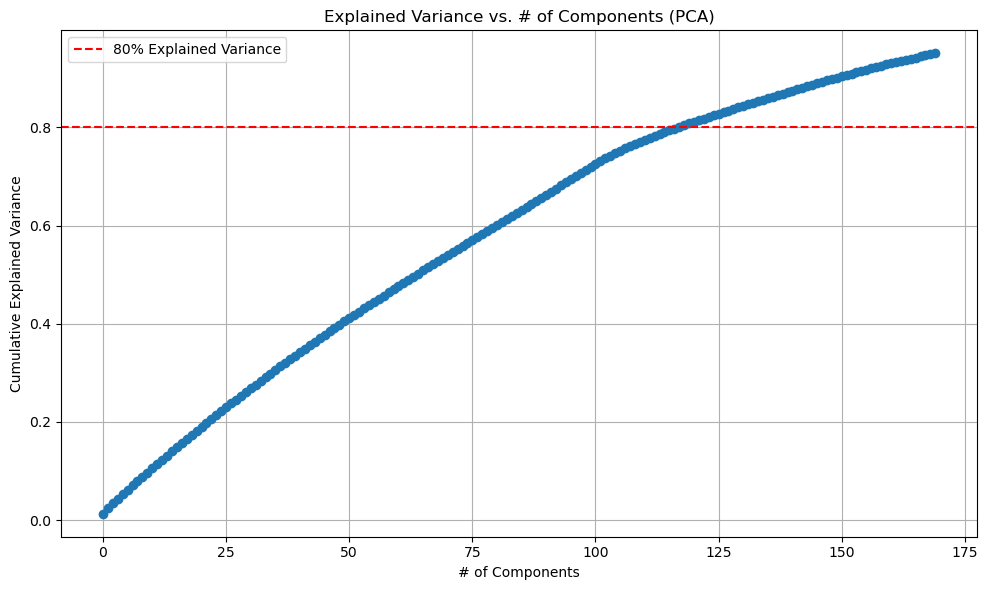

In [22]:
# select target numeric cols:
numeric_cols = f1_pit_df.select_dtypes(include=['float64', 'int64']).columns
X = f1_pit_df[numeric_cols].drop(columns=['PitTime_Secs'], errors="ignore")
y = f1_pit_df['PitTime_Secs']

# handle any nans:
X = X.fillna(X.median(numeric_only=True))

# standardize the data and scale:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# define components and PCA:
pca = PCA(n_components=.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# plot explained variance: 
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Explained Variance vs. # of Components (PCA)')
plt.xlabel('# of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=.8, color='r', linestyle='--', label='80% Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# display the shape of the original vs transformed data with pca:
print(f"Original data shape: {X.shape}")
print(f"PCA transformed data shape: {X_pca.shape}")
print(f"# of components selected: {pca.n_components}")
print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.2f}")

Original data shape: (9921, 328)
PCA transformed data shape: (9921, 170)
# of components selected: 0.95
Total explained variance: 0.95


In [24]:
#### Future - use X_pca with an ML model to predict PitTime_Secs and to predict potential race strategies for teams?

## Model Building
TBA

In [25]:
# model init
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", random_state=42)
lr = LogisticRegression(max_iter=200, class_weight="balanced", random_state=42)
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=.05, max_depth=3, random_state=42)

# run
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
gb.fit(X_train, y_train)

# evaluate different models:
models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Gradient Boosting": gb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    results.append({"Model": name, "Accuracy": acc, "Macro F1 Score": f1_macro})

    print(f"\n{name}")
    print("-" * len(name))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report: ")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="Macro F1 Score", ascending=False)
results_df

C:\Users\iseah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Random Forest
-------------
Confusion Matrix
[[288  36   1]
 [ 14 496  21]
 [  0  82 106]]

Classification Report: 
              precision    recall  f1-score   support

           1       0.95      0.89      0.92       325
           2       0.81      0.93      0.87       531
          3+       0.83      0.56      0.67       188

    accuracy                           0.85      1044
   macro avg       0.86      0.79      0.82      1044
weighted avg       0.86      0.85      0.85      1044


Logistic Regression
-------------------
Confusion Matrix
[[246  69  10]
 [ 31 392 108]
 [  0  61 127]]

Classification Report: 
              precision    recall  f1-score   support

           1       0.89      0.76      0.82       325
           2       0.75      0.74      0.74       531
          3+       0.52      0.68      0.59       188

    accuracy                           0.73      1044
   macro avg       0.72      0.72      0.72      1044
weighted avg       0.75      0.73      0.74    

,Model,Accuracy,Macro F1 Score
2,Gradient Boosting,0.879310,0.865729
0,Random Forest,0.852490,0.818641
1,Logistic Regression,0.732759,0.716140


## Hyperparameter Tuning
TBA

In [26]:
# TODO: RF tuning (GridSearchCV)
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=1),
    rf_param_grid, 
    cv=3, 
    scoring="f1_macro", 
    n_jobs=1)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print("Best Params (Random Forest): ", rf_grid.best_params_)
print("Best CV Score (Random Forest): ", rf_grid.best_score_)

Best Params (Random Forest):  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score (Random Forest):  0.8430544890128212


In [27]:
# TODO: LR tuning (GridSearchCV)
lr_param_grid = {
    "C": [.01, .1, 1, 10],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42),
    lr_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_

print("Best Params (Logistic Regression): ", lr_grid.best_params_)
print("Best CV Score (Logistic Regression): ", lr_grid.best_score_)

Best Params (Logistic Regression):  {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV Score (Logistic Regression):  0.7230332377491698


C:\Users\iseah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# TODO: GB tuning (GridSearchCV)
gb_param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [.01, .05, .1],
    "max_depth": [2, 3, 4],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=1,
    verbose=True
)

gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

print("Best Params (Gradient Boosting): ", gb_grid.best_params_)
print("Best CV Score (Gradient Boosting): ", gb_grid.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Params (Gradient Boosting):  {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV Score (Gradient Boosting):  0.9014928383334437


In [30]:
# Evaluate and compare tuned models:

tuned_models = {
    "Tuned Random Forest": rf_best,
    "Tuned Logistic Regression": lr_best,
    "Tuned Gradient Boosting": gb_best
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    tuned_results.append({"Model": name, "Accuracy": acc, "Macro F1 Score": f1_macro})

    print(f"\n{name}")
    print("-" * len(name))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report: ")
    print(classification_report(y_test, y_pred))

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="Macro F1 Score", ascending=False)
tuned_results_df


Tuned Random Forest
-------------------
Confusion Matrix
[[293  31   1]
 [ 19 473  39]
 [  1  62 125]]

Classification Report: 
              precision    recall  f1-score   support

           1       0.94      0.90      0.92       325
           2       0.84      0.89      0.86       531
          3+       0.76      0.66      0.71       188

    accuracy                           0.85      1044
   macro avg       0.84      0.82      0.83      1044
weighted avg       0.85      0.85      0.85      1044


Tuned Logistic Regression
-------------------------
Confusion Matrix
[[289  33   3]
 [ 68 349 114]
 [  1  52 135]]

Classification Report: 
              precision    recall  f1-score   support

           1       0.81      0.89      0.85       325
           2       0.80      0.66      0.72       531
          3+       0.54      0.72      0.61       188

    accuracy                           0.74      1044
   macro avg       0.72      0.75      0.73      1044
weighted avg       0.76

,Model,Accuracy,Macro F1 Score
2,Tuned Gradient Boosting,0.920498,0.911547
0,Tuned Random Forest,0.853448,0.829687
1,Tuned Logistic Regression,0.740421,0.727740


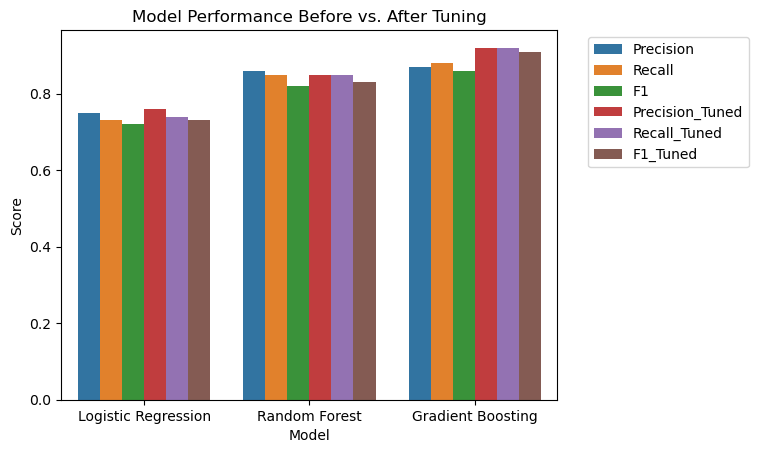

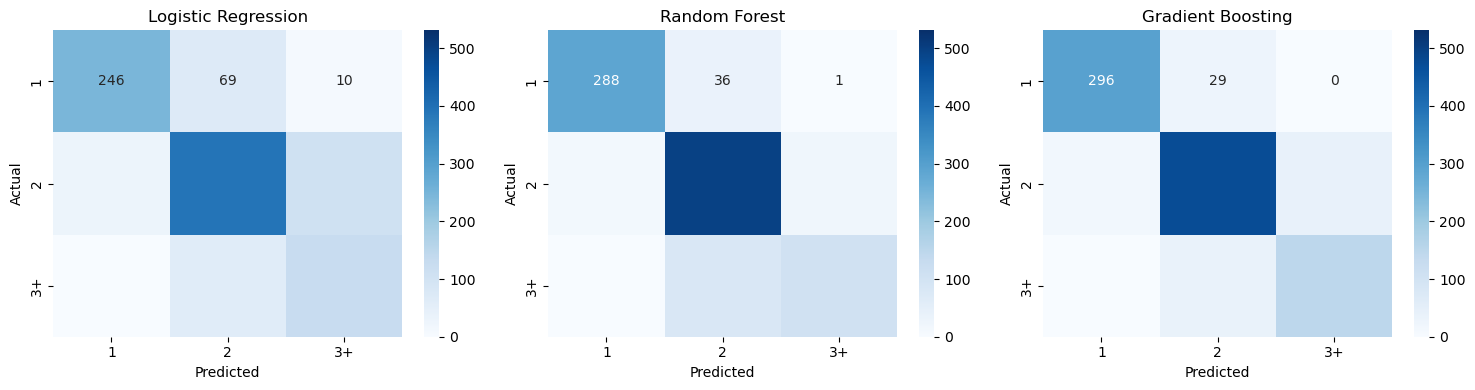

In [51]:
# visualize these evaluations w/ plot:
df_eval = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [.75, .86, .87], 
    'Recall': [.73, .85, .88],
    'F1': [.72, .82, .86],

    'Precision_Tuned': [.76, .85, .92],
    'Recall_Tuned': [.74, .85, .92],
    'F1_Tuned': [.73, .83, .91],
})

df_eval_melt = df_eval.melt(id_vars ='Model', var_name='Metric', value_name='Score')

plt.figure()
sns.barplot(data=df_eval_melt, x='Model', y='Score', hue='Metric')
plt.title("Model Performance Before vs. After Tuning")
plt.legend(bbox_to_anchor=(1.4, 1), loc='upper right')
plt.show()

# confusion matrices:
fix, axes = plt.subplots(1, 3, figsize=(15, 4))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['1', '2', '3+'], yticklabels=['1', '2', '3+'], vmin=0, vmax=531, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Development Summary
TBA

## Challenges
As part of this project, there were several challenges that I faced during the preprocessing stage:
- **Time Format Inconsistency:** Initially, the pit stop times weren't purely numeric, but were object variables in HH:MM:SS, which would be counterintuitive for data analysis. To address this, I converted the pit stop times from said format into seconds with a function converting all of the time values into seconds for more consistency.
- **Missing (NaN) values:** There were some variables that were missing after I encoded the categorical variables, so I needed to impute these values with median and mode imputations for numerical and categorical variables, respectively, to ensure a complete dataset.
- **Data Structure Misalignment:** Originally, the dataset was recorded at the pit-stop level, but performing data analysis at this level would be complicated since it did not directly represent race strategies; so I had to aggreegate the data to the race-driver level where each row represents a complete race strategy for a driver.
- **Class Imbalance:** The target variable (number of pit stops) was imbalanced as most of the observations were concentrated in 1 or 2-stop pit strategies. To address this, I grouped these categories into broader classes (1, 2, and 3+ stops) to balance the classes.
- **High Dimensionality:** After applying OHE, the dimensionality became large with the amount of new features that were introduced, which is why I used PCA to retain the most important features and reduce dimensionality at the same time.